# GridSearch SVM - Sin HbA1c_level ni blood_glucose_level

## 1. Objetivo

Optimizar los hiperparametros de una SVM con kernel RBF para la deteccion de diabetes, excluyendo `HbA1c_level` y `blood_glucose_level` por fuga de informacion. Se busca maximizar el equilibrio entre Precision y Recall mediante **Average Precision (PR-AUC)** como funcion de scoring.

## 2. Dataset y preprocesado

Identico al notebook `baseline_sin_hba1c_glucose.ipynb`: 
- Carga y limpieza desde `data/diabetes_prediction_dataset.csv`.
- Eliminacion de `HbA1c_level` y `blood_glucose_level`.
- Variables numericas (`age`, `bmi`): `StandardScaler`.
- Variables categoricas (`gender`, `smoking_history`): `OneHotEncoder(drop='first')`.
- Variables binarias (`hypertension`, `heart_disease`): `passthrough`.
- Division estratificada 80/20 train/test.
- Para acelerar el GridSearch se usa un **subconjunto del 20% del train** (~16k muestras) porque SVM RBF es O(n^2).

## 3. Espacio de busqueda (Grid)

Se exploran **18 combinaciones** (3x2x3) con 3-fold CV:

| Hiperparametro | Valores | Justificacion |
|---------------|---------|---------------|
| `C` | `[0.1, 0.5, 1]` | Controla la regularizacion. Valores bajos (0.1) generan margen mas suave; valores altos (1) se ajustan mas a los datos. Se evitan valores extremos (>1) porque con 80k muestras el modelo ya tiene suficiente capacidad. |
| `gamma` | `['scale', 0.01]` | Controla la influencia de cada punto de entrenamiento. `'scale'` = 1/(n_features * X.var()) se adapta a los datos; 0.01 da una influencia mas amplia (modelo mas suave). Se evita 0.1 porque es casi identico a 'scale' y no anade diversidad. |
| `class_weight` | `['balanced', {0:1,1:5}, {0:1,1:10}]` | `'balanced'` da peso ~5.9 a la clase positiva; `{0:1,1:5}` y `{0:1,1:10}` permiten explorar pesos intermedios y mas agresivos para la clase minoritaria. |

### 3.1. ¿Por que estos hiperparametros?

- **C**: La regularizacion controla el equilibrio entre sesgo y varianza. Con pocos datos (subset 16k) valores extremos como C=100 pueden overfitted facilmente.
- **gamma**: En SVM RBF, gamma determina el radio de influencia de cada punto. `'scale'` es la opcion mas robusta; 0.01 permite probar un modelo mas sencillo.
- **class_weight**: Es el parametro mas influyente en problemas desbalanceados. Se exploran desde el peso automatico de `'balanced'` hasta un peso fijo 10:1 para la clase positiva.

## 4. Scoring: Average Precision (PR-AUC)

Se usa `scoring='average_precision'` (built-in de sklearn) que calcula el area bajo la curva Precision-Recall.

### ¿Por que PR-AUC y no otra metrica?

| Metrica | Problema |
|---------|---------|
| **Accuracy** | Enganosa en desbalance (predecir siempre '0' da 91.5%). |
| **Recall** | Optimizar Recall puro lleva a modelos con Precision muy baja (muchos FP). Ya lo comprobamos: con `{0:1,1:20}` obtuvimos Recall 0.968 pero Precision 0.345. |
| **F1** | Buen equilibrio, pero no captura el comportamiento completo del modelo ante diferentes umbrales. |
| **ROC-AUC** | Pondera por igual TP y TN; en desbalance se ve artificialmente optimista. |
| **PR-AUC** | Se centra en la clase positiva (diabetes). Evalua el modelo en todo el rango de umbrales. Es la metrica mas informativa para problemas con clase minoritaria. |

PR-AUC es adecuada para un problema medico porque: (1) se enfoca en la clase de interes (diabeticos), (2) penaliza tanto los FP como los FN de forma implicita al considerar la curva completa, y (3) no se ve inflada por los TN mayoritarios.

## 5. Comparacion con baseline

Los resultados del GridSearch se comparan con el modelo baseline (`C=1, class_weight='balanced', gamma='scale'`) usando las metricas conocidas de ejecuciones anteriores. Si existe un modelo pre-entrenado guardado en `artifacts/svm_model_trained.pkl`, se carga para generar la curva PR y la matriz de confusion del baseline.

## 6. Interpretacion de resultados

Tras el GridSearch se obtiene la combinacion optima de hiperparametros que maximiza PR-AUC en validacion cruzada. Luego:
1. Se **refitea** el modelo con esos parametros en el train completo (80k muestras) con `probability=True`.
2. Se evalua en test y se comparan las metricas con el baseline.
3. Se muestra la matriz de confusion para visualizar FP y FN.

## 7. Threshold tuning

Adicionalmente, se analiza como variaria el equilibrio Precision-Recall al modificar el umbral de decision (por defecto 0.5). Esto permite al clinician elegir el punto de operacion mas adecuado segun el coste relativo de FP y FN en su contexto.

## 8. Limitaciones

- El GridSearch se realiza sobre un subconjunto del 20% del train (~16k) para ser computacionalmente viable. Los parametros optimos podrian diferir ligeramente de los que se obtendrian con el dataset completo.
- `probability=True` ralentiza el entrenamiento porque sklearn realiza validacion cruzada interna para calibrar las probabilidades (Platt scaling).
- Sin HbA1c y glucosa el modelo pierde poder predictivo respecto a versiones anteriores del experimento.

---
## Ejecucion del GridSearch

In [1]:
import sys
sys.path.insert(0, '.')
import pandas as pd
import numpy as np
from time import time
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import shap
import seaborn as sns
from SVM_model.pipeline import load_data, clean_data, merge_smoking
import warnings; warnings.filterwarnings('ignore')
print('Listo')


Listo


In [2]:
# Carga y limpieza estandar
df = load_data()
df = clean_data(df)
df = merge_smoking(df)
print(f'Dataset: {df.shape}')


Dataset: (99935, 9)


In [3]:
# Eliminamos HbA1c_level y blood_glucose_level (fuga de informacion)
X = df.drop(columns=['diabetes', 'HbA1c_level', 'blood_glucose_level'])
y = df['diabetes']
print(f'Features ({X.shape[1]}): {list(X.columns)}')


Features (6): ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi']


In [4]:
NUM = ['age', 'bmi']
CAT = ['gender', 'smoking_history']
BIN = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM),
    ('cat', OneHotEncoder(drop='first'), CAT),
    ('bin', 'passthrough', BIN)
])
print('Preprocesador listo')


Preprocesador listo


In [5]:
# Division estratificada 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Subset del 20% del train para acelerar GridSearch (SVM RBF es O(n^2))
X_gs, _, y_gs, _ = train_test_split(
    X_train, y_train, test_size=0.8, random_state=42, stratify=y_train
)
print(f'GridSearch subset: {X_gs.shape}')


Train: (79948, 6), Test: (19987, 6)
GridSearch subset: (15989, 6)


In [6]:
# Pipeline base sin fijar hiperparametros (se buscaran en GridSearch)
# Nota: probability=True necesario para scoring='average_precision'
base_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(random_state=42, probability=True))
])
print('Pipeline base listo')


Pipeline base listo


In [7]:
# Espacio de busqueda: 3 C x 2 gamma x 3 class_weight = 18 combinaciones
param_grid = {
    'svm__C': [0.1, 0.5, 1],
    'svm__gamma': ['scale', 0.01],
    'svm__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}
total = 1
for v in param_grid.values():
    total *= len(v)
print(f'Combinaciones: {total}, 3-fold CV => {total*3} fits')


Combinaciones: 18, 3-fold CV => 54 fits


In [8]:
# GridSearchCV con 3-fold CV, optimizando Average Precision (PR-AUC)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    base_pipeline, param_grid,
    scoring='average_precision',
    cv=cv, n_jobs=-1
)

print('Ejecutando GridSearch sobre subset 20%...')
t0 = time()
grid_search.fit(X_gs, y_gs)
print(f'Completado en {time()-t0:.0f}s')
print(f'Mejor Average Precision (CV): {grid_search.best_score_:.4f}')
print(f'Mejores parametros:')
for p, v in grid_search.best_params_.items():
    print(f'  {p}: {v}')


Ejecutando GridSearch sobre subset 20%...


Completado en 174s
Mejor Average Precision (CV): 0.3127
Mejores parametros:
  svm__C: 0.5
  svm__class_weight: {0: 1, 1: 5}
  svm__gamma: 0.01


In [9]:
# Refiteamos en train completo con los mejores parametros
best_C = grid_search.best_params_['svm__C']
best_g = grid_search.best_params_['svm__gamma']
best_cw = grid_search.best_params_['svm__class_weight']

final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='rbf', C=best_C, gamma=best_g,
                class_weight=best_cw, probability=True,
                random_state=42))
])

print('Refiteando en train completo (80k muestras)...')
t0 = time()
final_model.fit(X_train, y_train)
print(f'Refit completado en {time()-t0:.0f}s')


Refiteando en train completo (80k muestras)...


Refit completado en 802s


In [10]:
# Evaluacion en test
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print()
print('='*55)
print('  RESULTADOS OPTIMIZADOS (sin HbA1c/glucosa)')
print('='*55)
print(f'  Mejores params: C={best_C}, gamma={best_g}, cw={best_cw}')
print(f'  Precision:             {precision:.4f}')
print(f'  Recall:                {recall:.4f}')
print(f'  F1:                    {f1:.4f}')
print(f'  ROC-AUC:               {roc_auc:.4f}')
print(f'  PR-AUC:                {pr_auc:.4f}')
print()
print(f'  Matriz de confusion:')
print(f'  TN:{tn:5d}  FP:{fp:5d}')
print(f'  FN:{fn:5d}  TP:{tp:5d}')
print('='*55)



  RESULTADOS OPTIMIZADOS (sin HbA1c/glucosa)
  Mejores params: C=0.5, gamma=0.01, cw={0: 1, 1: 5}
  Precision:             0.2999
  Recall:                0.4797
  F1:                    0.3691
  ROC-AUC:               0.8314
  PR-AUC:                0.3075

  Matriz de confusion:
  TN:16390  FP: 1900
  FN:  883  TP:  814


Features: 8 -> ['num__age', 'num__bmi', 'cat__gender_Male', 'cat__smoking_history_NeverSmoked', 'cat__smoking_history_NoInfo', 'cat__smoking_history_Smoking', 'bin__hypertension', 'bin__heart_disease']
Xp_train: (79948, 8), Xp_test: (19987, 8)
Computando SHAP values (20 muestras, ~2 min)...


  0%|          | 0/20 [00:00<?, ?it/s]

Completado en 116s
sv type: ndarray, len: 20, sv[0] shape: (8, 2)
shap_class1: (20, 8)


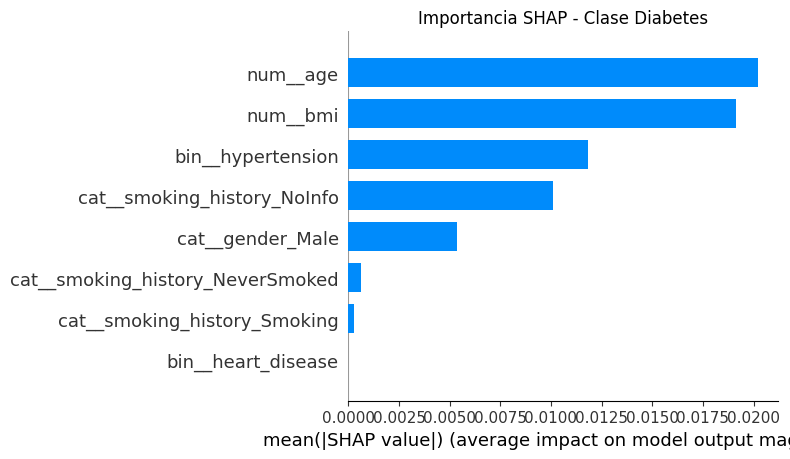

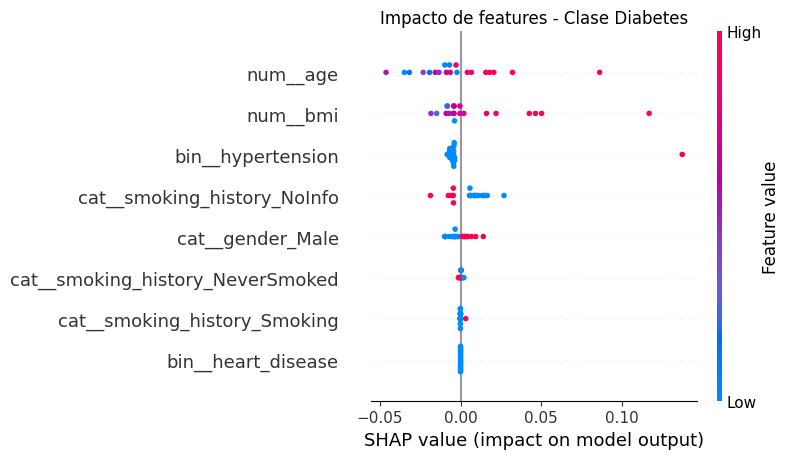

In [11]:
# SHAP values - explicabilidad del modelo
Xp_train = final_model.named_steps['preprocessor'].transform(X_train)
Xp_test = final_model.named_steps['preprocessor'].transform(X_test)
fnames = list(final_model.named_steps['preprocessor'].get_feature_names_out())
print(f'Features: {len(fnames)} -> {fnames}')
print(f'Xp_train: {Xp_train.shape}, Xp_test: {Xp_test.shape}')

# Background para KernelExplainer (30 muestras)
rng = np.random.default_rng(42)
bg = Xp_train[rng.choice(Xp_train.shape[0], 30, replace=False)]
explainer = shap.KernelExplainer(
    final_model.named_steps['svm'].predict_proba, bg
)

# Explicar 20 muestras de test
X_shap = Xp_test[rng.choice(Xp_test.shape[0], 20, replace=False)]
print('Computando SHAP values (20 muestras, ~2 min)...')
t0 = time()
sv = explainer.shap_values(X_shap, nsamples=100)
print(f'Completado en {time()-t0:.0f}s')
print(f'sv type: {type(sv).__name__}, len: {len(sv)}, sv[0] shape: {sv[0].shape}')

# shap 0.52 devuelve lista por muestra: sv[i] = (n_features, n_outputs)
# Convertir a formato clasico: (n_samples, n_features) para clase 1
n = X_shap.shape[0]
if len(sv) == 2 and sv[0].shape[0] == n:
    shap_class1 = sv[1]  # formato antiguo
else:
    shap_class1 = np.array([sv_i[:, 1] for sv_i in sv])  # formato nuevo
print(f'shap_class1: {shap_class1.shape}')

# SHAP plots
if shap_class1.shape[1] == X_shap.shape[1]:
    feat = fnames[:shap_class1.shape[1]]
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, plot_type='bar', show=False)
    plt.title('Importancia SHAP - Clase Diabetes')
    plt.tight_layout(); plt.show()
    shap.summary_plot(shap_class1, X_shap, feature_names=feat, show=False)
    plt.title('Impacto de features - Clase Diabetes')
    plt.tight_layout(); plt.show()
else:
    print(f'Shape mismatch: shap_class1={shap_class1.shape} vs X_shap={X_shap.shape}')


In [12]:
# Baseline con probability=True en el subset 20% (rapido, ~16k muestras)
base_model = Pipeline([
    ('preprocessor', preprocessor),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale',
                class_weight='balanced', probability=True,
                random_state=42))
])
# Usamos X_gs (subset 20% del train) para mantener tiempo acotado
t0 = time()
base_model.fit(X_gs, y_gs)
y_pred_base = base_model.predict(X_test)
y_proba_base = base_model.predict_proba(X_test)[:, 1]
cm_base = confusion_matrix(y_test, y_pred_base)

base_metrics = {
    'Precision': precision_score(y_test, y_pred_base),
    'Recall': recall_score(y_test, y_pred_base),
    'F1': f1_score(y_test, y_pred_base),
    'PR-AUC': average_precision_score(y_test, y_proba_base),
    'ROC-AUC': roc_auc_score(y_test, y_proba_base)
}

opt_metrics = {
    'Precision': precision, 'Recall': recall, 'F1': f1,
    'PR-AUC': pr_auc, 'ROC-AUC': roc_auc
}
comp = pd.DataFrame({'Baseline (propio)': base_metrics, 'Optimizado': opt_metrics})
comp['Mejora'] = comp['Optimizado'] - comp['Baseline (propio)']
print()
print('Comparacion Baseline propio vs Optimizado:')
print(comp.round(4).to_string())



Comparacion Baseline propio vs Optimizado:
           Baseline (propio)  Optimizado  Mejora
Precision             0.2036      0.2999  0.0963
Recall                0.8161      0.4797 -0.3365
F1                    0.3259      0.3691  0.0432
PR-AUC                0.2520      0.3075  0.0555
ROC-AUC               0.8175      0.8314  0.0139


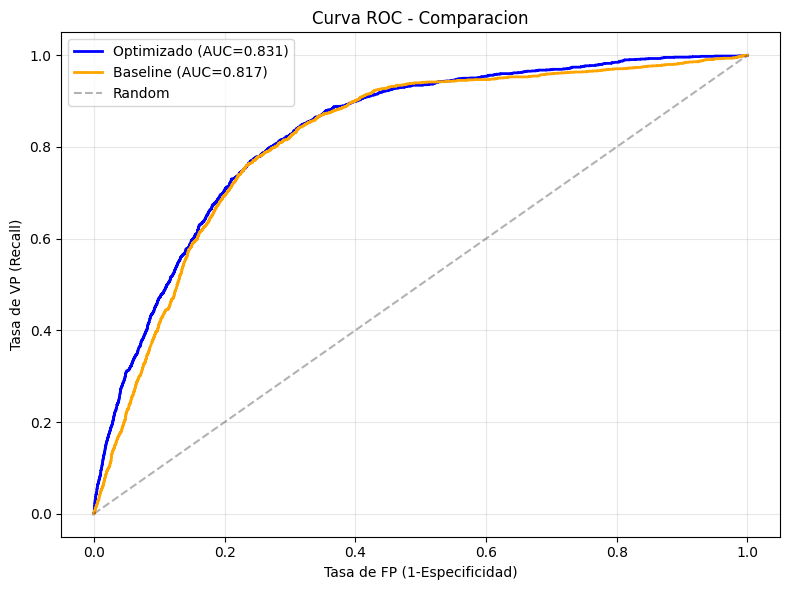

In [13]:
# Curva ROC comparativa: Baseline vs Optimizado
from sklearn.metrics import roc_curve
fpr_opt, tpr_opt, _ = roc_curve(y_test, y_proba)
fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_opt, tpr_opt, 'b-', lw=2, label=f'Optimizado (AUC={roc_auc:.3f})')
ax.plot(fpr_base, tpr_base, 'orange', lw=2, label=f'Baseline (AUC={base_metrics["ROC-AUC"]:.3f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set(xlabel='Tasa de FP (1-Especificidad)', ylabel='Tasa de VP (Recall)',
       title='Curva ROC - Comparacion')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


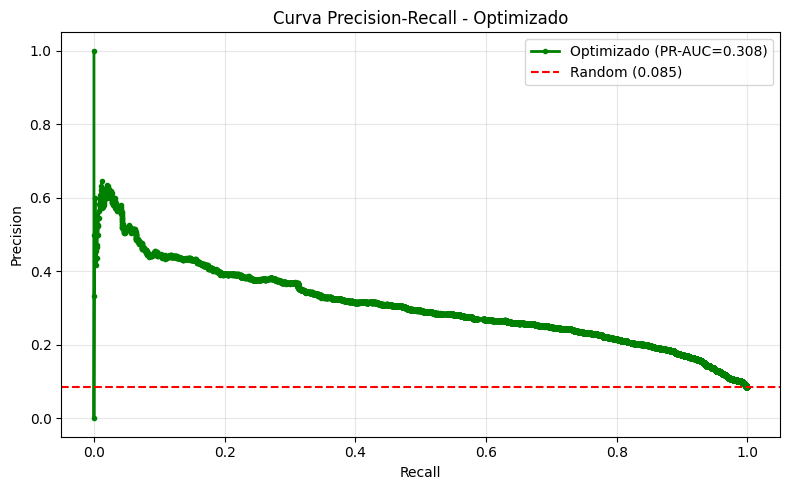

In [14]:
# Curva Precision-Recall del modelo optimizado (solamente)
pr, re, _ = precision_recall_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(re, pr, marker='.', label=f'Optimizado (PR-AUC={pr_auc:.3f})', color='green', lw=2)
ax.axhline(y=y_test.mean(), color='red', ls='--', label=f'Random ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='Curva Precision-Recall - Optimizado')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


Threshold optimo (max F1): 0.10
  Precision: 0.2710  (default: 0.2999)
  Recall:    0.5875  (default: 0.4797)
  F1:        0.3709  (default: 0.3691)


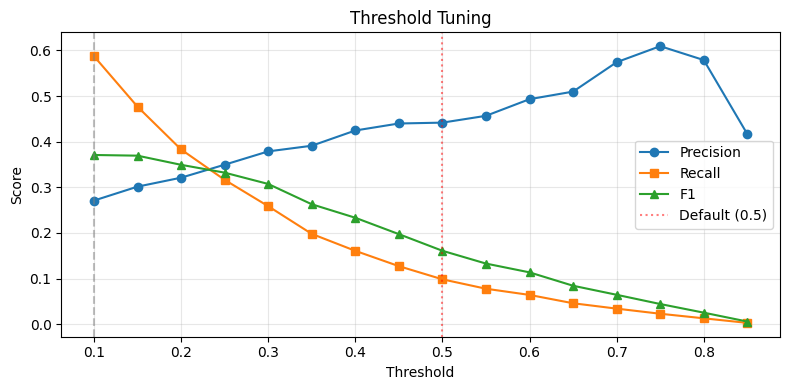

In [15]:
# Ajuste de umbral para balancear Precision-Recall sin reentrenar
thresholds = np.arange(0.1, 0.9, 0.05)
scores = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    scores.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t),
        'recall': recall_score(y_test, y_pred_t),
        'f1': f1_score(y_test, y_pred_t)
    })
df_t = pd.DataFrame(scores)
best_t = df_t.loc[df_t['f1'].idxmax()]
print(f'Threshold optimo (max F1): {best_t["threshold"]:.2f}')
print(f'  Precision: {best_t["precision"]:.4f}  (default: {precision:.4f})')
print(f'  Recall:    {best_t["recall"]:.4f}  (default: {recall:.4f})')
print(f'  F1:        {best_t["f1"]:.4f}  (default: {f1:.4f})')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_t['threshold'], df_t['precision'], label='Precision', marker='o')
ax.plot(df_t['threshold'], df_t['recall'], label='Recall', marker='s')
ax.plot(df_t['threshold'], df_t['f1'], label='F1', marker='^')
ax.axvline(x=best_t['threshold'], color='gray', ls='--', alpha=0.5)
ax.axvline(x=0.5, color='red', ls=':', alpha=0.5, label='Default (0.5)')
ax.set(xlabel='Threshold', ylabel='Score', title='Threshold Tuning')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


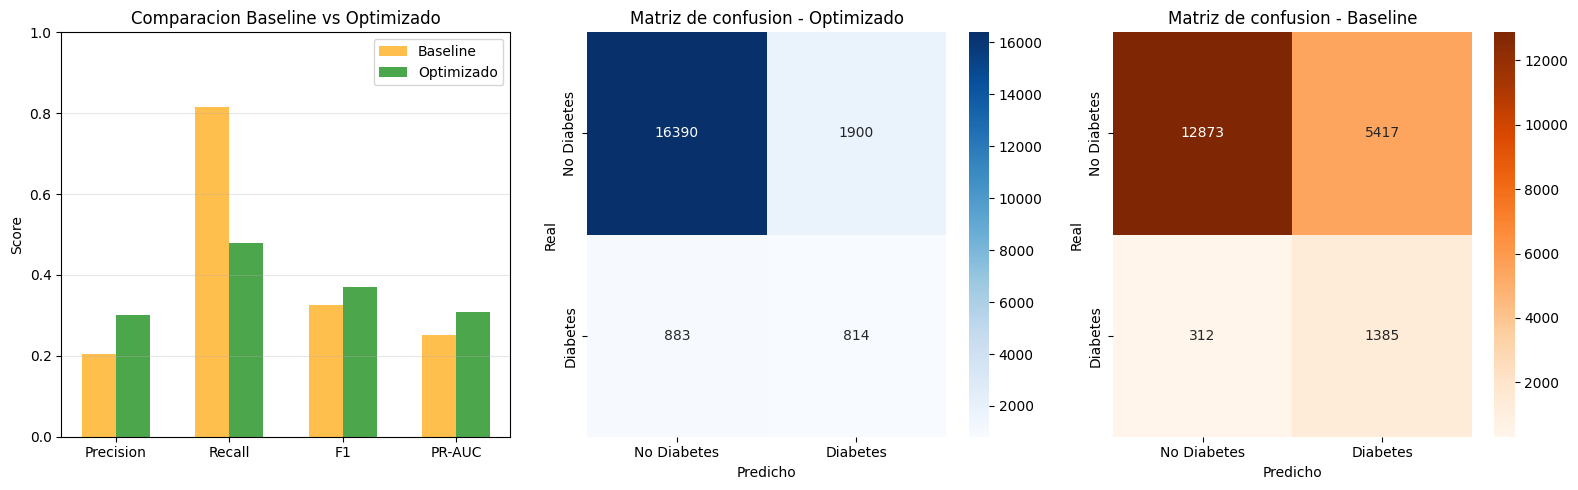

In [16]:
# Grafico comparativo de metricas y matrices de confusion
fig, axes = plt.subplots(1, 3 if cm_base is not None else 2, figsize=(16 if cm_base is not None else 13, 5))
metrics = ['Precision', 'Recall', 'F1', 'PR-AUC']
x = np.arange(len(metrics)); w = 0.3
base_vals = [base_metrics[m] for m in metrics]
opt_vals = [opt_metrics[m] for m in metrics]
axes[0].bar(x - w/2, base_vals, w, label='Baseline', color='orange', alpha=0.7)
axes[0].bar(x + w/2, opt_vals, w, label='Optimizado', color='green', alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score'); axes[0].set_ylim([0, 1])
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
axes[0].set_title('Comparacion Baseline vs Optimizado')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
axes[1].set_title('Matriz de confusion - Optimizado')
axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicho')

if cm_base is not None:
    sns.heatmap(cm_base, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    axes[2].set_title('Matriz de confusion - Baseline')
    axes[2].set_ylabel('Real'); axes[2].set_xlabel('Predicho')

plt.tight_layout(); plt.show()
